In [49]:
import numpy as np
import pandas as pd

In [50]:
df = pd.read_csv('./placement.csv')

In [51]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [53]:
df = df.iloc[:,1:]

In [54]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [55]:
import matplotlib.pyplot as plt

In [56]:
df.columns

Index(['cgpa', 'iq', 'placement'], dtype='object')

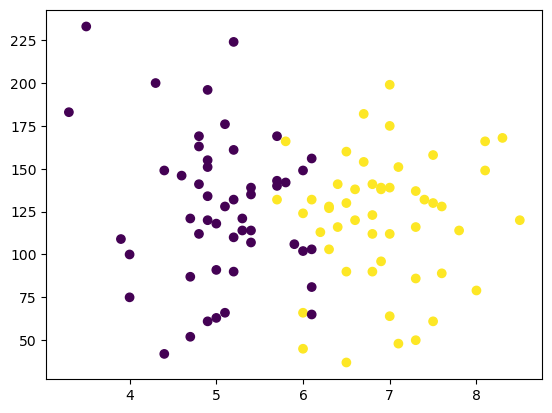

In [57]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [58]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [59]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [60]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [61]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [62]:
X_train

,cgpa,iq
37,8.1,149.0
67,5.0,118.0
44,7.5,61.0
30,7.6,128.0
77,7.3,50.0
...,...,...
27,6.0,124.0
66,6.9,96.0
9,5.1,66.0
95,4.3,200.0


In [63]:
from sklearn.preprocessing import StandardScaler

In [64]:
scaler = StandardScaler()

In [65]:
X_train = scaler.fit_transform(X_train)

In [66]:
X_train

array([[ 1.7979841 ,  0.69804515],
       [-0.91944582, -0.09299708],
       [ 1.27202992, -1.54749408],
       [ 1.35968895,  0.16217783],
       [ 1.09671186, -1.82818649],
       [-0.13051456, -0.39920697],
       [-1.09476388, -0.24610203],
       [-1.27008194,  0.62149268],
       [-1.4454    , -2.03232642],
       [-0.30583261,  0.2642478 ],
       [ 0.65841671, -0.80748683],
       [-0.91944582, -1.4964591 ],
       [-2.40964933,  1.56563985],
       [-0.04285553, -1.95577394],
       [-0.83178679,  1.38701741],
       [-1.00710485,  0.31528278],
       [-0.5688097 , -0.19506704],
       [-1.79603612, -1.1902492 ],
       [-0.65646873, -0.01644461],
       [ 0.22012156, -0.47575945],
       [-0.5688097 ,  0.44287024],
       [-0.74412776, -0.80748683],
       [-1.00710485,  0.8511501 ],
       [-0.83178679,  0.16217783],
       [ 0.39543962,  0.21321282],
       [-1.00710485, -1.54749408],
       [-0.21817358,  1.1318425 ],
       [-0.5688097 , -0.37368948],
       [-0.65646873,

In [67]:
X_test = scaler.transform(X_test)

In [68]:
from sklearn.linear_model import LogisticRegression

In [69]:
clf = LogisticRegression()

In [70]:
# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [73]:
y_pred = clf.predict(X_test)

In [72]:
y_test

50    0
51    0
71    1
56    0
89    0
38    1
24    0
92    0
43    1
8     0
Name: placement, dtype: int64

In [74]:
from sklearn.metrics import accuracy_score

In [75]:
accuracy_score(y_test,y_pred)

0.8

In [85]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

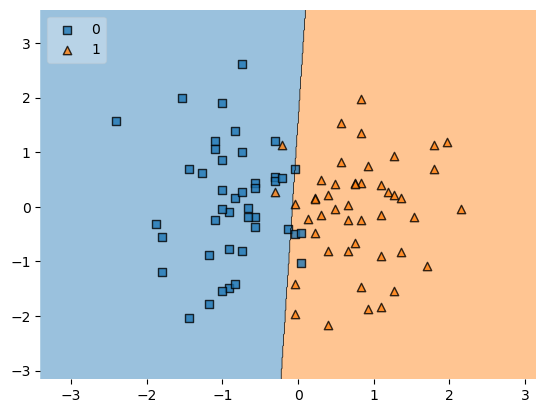

In [86]:
plot_decision_regions(X_train,y_train.values,clf=clf,legend=2)

In [87]:
import pickle

In [88]:
pickle.dump(clf,open('model.pkl','wb'))